<a href="https://colab.research.google.com/github/parthdasawant/DRL/blob/main/MAB/DRL_MAB_vs_ContextualMAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DEEP REINFORCEMENT LEARNING
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, usecase, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation, rewriting and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

## Objective:
1. Differentiate the intution of Multi Armed Bandit vs Contextual Multi Armed Bandit
2. Analyse the significance of below hyperparameters
    *   Epsilon - Exploration Parameter
    *   C- Confidence Control for UCB
    *   learning_rate - To control the action value update in MAB (only)
3. Interpret the effect of above hyperparameters in influencing the exploration vs explotation vs stability in learning process

**Exercise**
*   Change the reward distribution
*   Simulate non-stationary via reward distribution changes



#### Use Case

A navigation robot is placed in a controlled testbed environment. At each time step, it can choose one of four actions: move left, right, up, or down. The short-term goal of this experiment is to train the robot to favor moving south (down), since that direction yields higher expected rewards in the testbed. This experiment is not tied to the robot’s long-term mission, but serves as a demonstration of how reinforcement learning can adaptively discover favorable actions.

##### Scenario A

The reward depends on the action itself.
To achieve this, we design a Multi-Armed Bandit (MAB) framework that learns the expected reward pattern associated with each action and gradually biases the robot toward the optimal choice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


In [2]:

# Define actions
actions = ["Left", "Right", "Up", "Down"]

# Environment: reward probabilities for each action
true_rewards = [0.2, 0.5, 0.7, 0.9]  # underlying reward distribution

# Bot position
bot_position = [5, 5]  # start in middle of grid


In [7]:
def run_bandit(learning_rate, epsilon, confidence, steps=100):
    q_values = np.zeros(len(actions))  # estimated rewards
    action_counts = np.zeros(len(actions))
    rewards = []
    avg_rewards = []
    bot_position = [5, 5]
    positions = [bot_position.copy()]

    for t in range(steps):
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(len(actions))
        else:
            action = np.argmax(q_values + np.random.randn(len(actions)) * confidence)

        # Simulate reward
        #reward = np.random.rand() < true_rewards[action]
        variance = np.random.uniform(0.05, 2)
        reward = np.random.normal(loc=true_rewards[action], scale=np.sqrt(variance))
        rewards.append(reward)

        # Update Q-values
        action_counts[action] += 1
        q_values[action] += learning_rate * (reward - q_values[action])

        avg_rewards.append(np.mean(rewards))

        # Move bot
        if actions[action] == "Left":
            bot_position[0] -= 1
        elif actions[action] == "Right":
            bot_position[0] += 1
        elif actions[action] == "Up":
            bot_position[1] += 1
        elif actions[action] == "Down":
            bot_position[1] -= 1

        positions.append(bot_position.copy())

    print("No.of.Times.Action.Selected : ",action_counts)
    print("Estimated Return: ",q_values)
    print("Actual True Return: ",true_rewards)

    # Plot reward curve
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(avg_rewards, label="Average Reward")
    plt.xlabel("Steps")
    plt.ylabel("Reward")
    plt.title("Learning Curve")
    plt.legend()

    # Plot bot movement
    plt.subplot(1,2,2)
    xs, ys = zip(*positions)
    plt.plot(xs, ys, marker="o")
    plt.title("Bot Movement")
    plt.xlim(0,10)
    plt.ylim(0,10)
    plt.grid(True)
    plt.show()

print("A situation Invariant Pattern Learner")
# Interactive controls
learning_rate_slider = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description="Learning Rate")
epsilon_slider = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description="Epsilon")
confidence_slider = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description="Confidence")


ui = widgets.HBox([learning_rate_slider, epsilon_slider, confidence_slider])

out = widgets.Output()

def update_plot(change=None):
    with out:
        clear_output(wait=True)
        run_bandit(learning_rate_slider.value, epsilon_slider.value, confidence_slider.value)

for slider in [learning_rate_slider, epsilon_slider, confidence_slider]:
    slider.observe(update_plot, names="value")

display(ui, out)
update_plot()

A situation Invariant Pattern Learner


Output()

### Elaborative Code for MAB (Scenario A)

To get a deeper understanding of how the MAB agent learns, let's add code to visualize:

1.  **Q-Value Evolution:** How the estimated `q_values` change over time, ideally converging towards `true_rewards`.
2.  **Action Selection Frequency:** A bar plot showing how often each action is chosen, indicating if the agent successfully identifies the optimal action.

In [8]:
def run_bandit_elaborated(learning_rate, epsilon, confidence, steps=100):
    q_values = np.zeros(len(actions))
    action_counts = np.zeros(len(actions))
    rewards = []
    avg_rewards = []
    bot_position = [5, 5]
    positions = [bot_position.copy()]

    # Store Q-value history and action history for plotting
    q_value_history = [q_values.copy()]
    action_history = []

    for t in range(steps):
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(len(actions))
        else:
            # UCB-like selection (or noisy argmax)
            action = np.argmax(q_values + np.random.randn(len(actions)) * confidence)

        action_history.append(action)

        # Simulate reward
        variance = np.random.uniform(0.05, 2)
        reward = np.random.normal(loc=true_rewards[action], scale=np.sqrt(variance))
        rewards.append(reward)

        # Update Q-values
        action_counts[action] += 1
        q_values[action] += learning_rate * (reward - q_values[action])

        avg_rewards.append(np.mean(rewards))
        q_value_history.append(q_values.copy())

        # Move bot (for visualization only)
        if actions[action] == "Left":
            bot_position[0] -= 1
        elif actions[action] == "Right":
            bot_position[0] += 1
        elif actions[action] == "Up":
            bot_position[1] += 1
        elif actions[action] == "Down":
            bot_position[1] -= 1

        positions.append(bot_position.copy())

    print("No.of.Times.Action.Selected : ", action_counts)
    print("Estimated Return: ", q_values)
    print("Actual True Return: ", true_rewards)

    plt.figure(figsize=(15, 10))

    # Plot 1: Learning Curve
    plt.subplot(2, 2, 1)
    plt.plot(avg_rewards, label="Average Reward")
    plt.xlabel("Steps")
    plt.ylabel("Reward")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)

    # Plot 2: Bot Movement
    plt.subplot(2, 2, 2)
    xs, ys = zip(*positions)
    plt.plot(xs, ys, marker="o")
    plt.title("Bot Movement")
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.grid(True)

    # Plot 3: Q-Value Evolution
    plt.subplot(2, 2, 3)
    q_history_np = np.array(q_value_history)
    for i, action_name in enumerate(actions):
        plt.plot(q_history_np[:, i], label=f'Q({action_name})')
    plt.axhline(y=true_rewards[0], color='r', linestyle='--', label=f'True Reward (Left): {true_rewards[0]:.2f}')
    plt.axhline(y=true_rewards[1], color='g', linestyle='--', label=f'True Reward (Right): {true_rewards[1]:.2f}')
    plt.axhline(y=true_rewards[2], color='b', linestyle='--', label=f'True Reward (Up): {true_rewards[2]:.2f}')
    plt.axhline(y=true_rewards[3], color='m', linestyle='--', label=f'True Reward (Down): {true_rewards[3]:.2f}')
    plt.xlabel("Steps")
    plt.ylabel("Estimated Q-Value")
    plt.title("Q-Value Evolution")
    plt.legend()
    plt.grid(True)

    # Plot 4: Action Selection Frequency
    plt.subplot(2, 2, 4)
    action_counts_final = np.bincount(action_history, minlength=len(actions))
    plt.bar(actions, action_counts_final, color='skyblue')
    plt.xlabel("Action")
    plt.ylabel("Number of Times Selected")
    plt.title("Action Selection Frequency")
    plt.grid(axis='y')

    plt.tight_layout()
    plt.show()


print("A situation Invariant Pattern Learner (Elaborated)")
# Interactive controls
learning_rate_slider_elab = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description="Learning Rate")
epsilon_slider_elab = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description="Epsilon")
confidence_slider_elab = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description="Confidence")


ui_elab = widgets.HBox([learning_rate_slider_elab, epsilon_slider_elab, confidence_slider_elab])

out_elab = widgets.Output()

def update_plot_elab(change=None):
    with out_elab:
        clear_output(wait=True)
        run_bandit_elaborated(learning_rate_slider_elab.value, epsilon_slider_elab.value, confidence_slider_elab.value)

for slider in [learning_rate_slider_elab, epsilon_slider_elab, confidence_slider_elab]:
    slider.observe(update_plot_elab, names="value")

display(ui_elab, out_elab)
update_plot_elab()

A situation Invariant Pattern Learner (Elaborated)


Output()

##### Scenario B

The reward depends on the action as well as the robot's current position in the grid.
To achieve this, we design a Contextual Multi-Armed Bandit (MAB) framework that learns the expected reward pattern conditioned on state information associated with each action and gradually biases the robot toward the optimal choice.

In [4]:
# Bot position
bot_position = [5, 5]



In [5]:
# --- Tabular UCB ---
def tabular_ucb(state, q_values, counts, t, c=1.0):
    ucb_values = []
    for a in range(len(actions)):
        if counts[state][a] == 0:
            ucb_values.append(float('inf'))
        else:
            mean = q_values[state][a]
            bonus = c * np.sqrt(np.log(t+1) / counts[state][a])
            ucb_values.append(mean + bonus)
    return np.argmax(ucb_values)

# --- LinUCB ---
def linucb_action(context, A, b, alpha=1.0):
    p_values = []
    for a in range(len(actions)):
        A_inv = np.linalg.inv(A[a])
        theta = A_inv @ b[a]
        mean = context @ theta
        bonus = alpha * np.sqrt(context @ A_inv @ context.T)
        p_values.append(mean + bonus)
    return np.argmax(p_values)

def linucb_update(action, context, reward, A, b):
    A[action] += np.outer(context, context)
    b[action] += reward * context



In [6]:
# --- Experiment Runner ---
def run_bandit(method="Tabular", steps=100, alpha=1.0, c=1.0):
    rewards = []
    avg_rewards = []
    positions = [bot_position.copy()]

    if method == "Tabular":
        q_values = {}
        counts = {}
        for x in range(11):
            for y in range(11):
                q_values[(x,y)] = np.zeros(len(actions))
                counts[(x,y)] = np.zeros(len(actions))
    else:  # LinUCB
        d = 2  # context dimension (x,y)
        A = [np.identity(d) for _ in actions]
        b = [np.zeros(d) for _ in actions]

    pos = bot_position.copy()

    for t in range(steps):
        state = tuple(pos)
        context = np.array(pos)

        if method == "Tabular":
            action = tabular_ucb(state, q_values, counts, t, c)
        else:
            action = linucb_action(context, A, b, alpha)

        # Gaussian reward with random variance
        variance = np.random.uniform(0.05, 0.5)
        reward = np.random.normal(loc=true_rewards[action], scale=np.sqrt(variance))
        rewards.append(reward)

        if method == "Tabular":
            counts[state][action] += 1
            q_values[state][action] += (reward - q_values[state][action]) / counts[state][action]
        else:
            linucb_update(action, context, reward, A, b)

        avg_rewards.append(np.mean(rewards))

        # Move bot
        if actions[action] == "Left": pos[0] = max(0, pos[0]-1)
        elif actions[action] == "Right": pos[0] = min(10, pos[0]+1)
        elif actions[action] == "Up": pos[1] = min(10, pos[1]+1)
        elif actions[action] == "Down": pos[1] = max(0, pos[1]-1)
        positions.append(pos.copy())

    # Plot results
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(avg_rewards, label="Average Reward")
    plt.xlabel("Steps")
    plt.ylabel("Reward")
    plt.title(f"{method} Learning Curve")
    plt.legend()

    plt.subplot(1,2,2)
    xs, ys = zip(*positions)
    plt.plot(xs, ys, marker="o")
    plt.title("Bot Movement")
    plt.xlim(0,10)
    plt.ylim(0,10)
    plt.grid(True)
    plt.show()

print("**A situation Aware Decision Maker**")
# --- Interactive Controls ---
method_dropdown = widgets.Dropdown(options=["Tabular","LinUCB"], value="Tabular", description="Method")
alpha_slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description="Alpha (LinUCB)")
c_slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description="C (Tabular UCB)")

print("Caution : There is an inherent re-sampling noise influencing the rewards")

ui = widgets.HBox([method_dropdown, alpha_slider, c_slider])
out = widgets.Output()

def update_plot(change=None):
    with out:
        clear_output(wait=True)
        if method_dropdown.value == "Tabular":
            run_bandit(method="Tabular", steps=100, c=c_slider.value)
        else:
            run_bandit(method="LinUCB", steps=100, alpha=alpha_slider.value)


for w in [method_dropdown, alpha_slider, c_slider]:
    w.observe(update_plot, names="value")

display(ui, out)
update_plot()

**A situation Aware Decision Maker**
Caution : There is an inherent re-sampling noise influencing the rewards


Output()

### Elaborative Comparison: Tabular vs LinUCB

This code will run both methods side-by-side for a higher number of steps to show the 'Convergence'—how quickly each method finds the optimal 'Down' action (which has the true reward of 0.9).

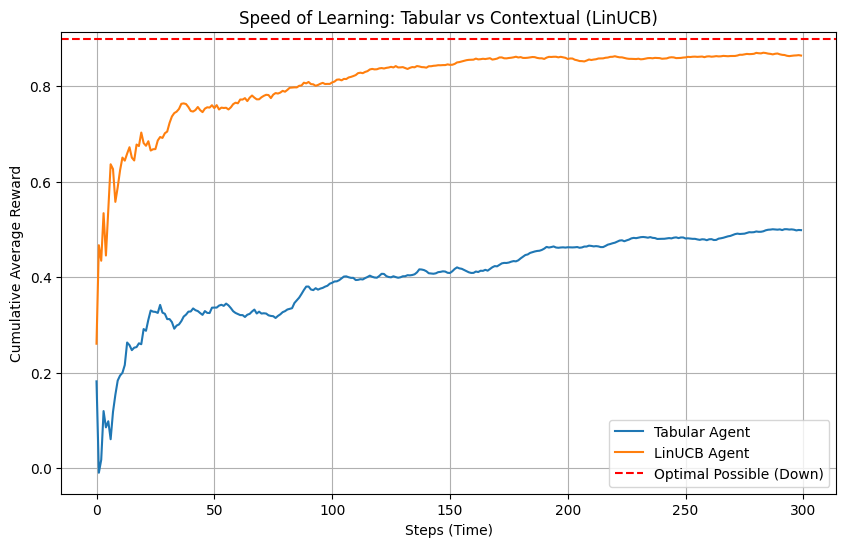

In [9]:
def run_comparison_experiment(steps=300):
    methods = ['Tabular', 'LinUCB']
    results = {m: [] for m in methods}

    for method in methods:
        pos = [5, 5]
        rewards = []
        avg_rewards = []

        if method == "Tabular":
            q_values = {(x,y): np.zeros(len(actions)) for x in range(11) for y in range(11)}
            counts = {(x,y): np.zeros(len(actions)) for x in range(11) for y in range(11)}
        else:
            A = [np.identity(2) for _ in actions]
            b = [np.zeros(2) for _ in actions]

        for t in range(steps):
            state = tuple(pos)
            context = np.array(pos)

            if method == "Tabular":
                action = tabular_ucb(state, q_values, counts, t, c=1.0)
            else:
                action = linucb_action(context, A, b, alpha=1.0)

            reward = np.random.normal(loc=true_rewards[action], scale=0.2)
            rewards.append(reward)

            if method == "Tabular":
                counts[state][action] += 1
                q_values[state][action] += (reward - q_values[state][action]) / counts[state][action]
            else:
                linucb_update(action, context, reward, A, b)

            avg_rewards.append(np.mean(rewards))

            # Movement logic
            if actions[action] == "Left": pos[0] = max(0, pos[0]-1)
            elif actions[action] == "Right": pos[0] = min(10, pos[0]+1)
            elif actions[action] == "Up": pos[1] = min(10, pos[1]+1)
            elif actions[action] == "Down": pos[1] = max(0, pos[1]-1)

        results[method] = avg_rewards

    plt.figure(figsize=(10, 6))
    for method in methods:
        plt.plot(results[method], label=f"{method} Agent")

    plt.axhline(y=0.9, color='r', linestyle='--', label="Optimal Possible (Down)")
    plt.title("Speed of Learning: Tabular vs Contextual (LinUCB)")
    plt.xlabel("Steps (Time)")
    plt.ylabel("Cumulative Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

run_comparison_experiment()

### Visualizing the Decision Surface (Brain of the Agent)

This final experiment visualizes what each agent has learned about the entire 11x11 grid. We color-code the grid based on which action the agent *estimates* is best for that specific coordinate.

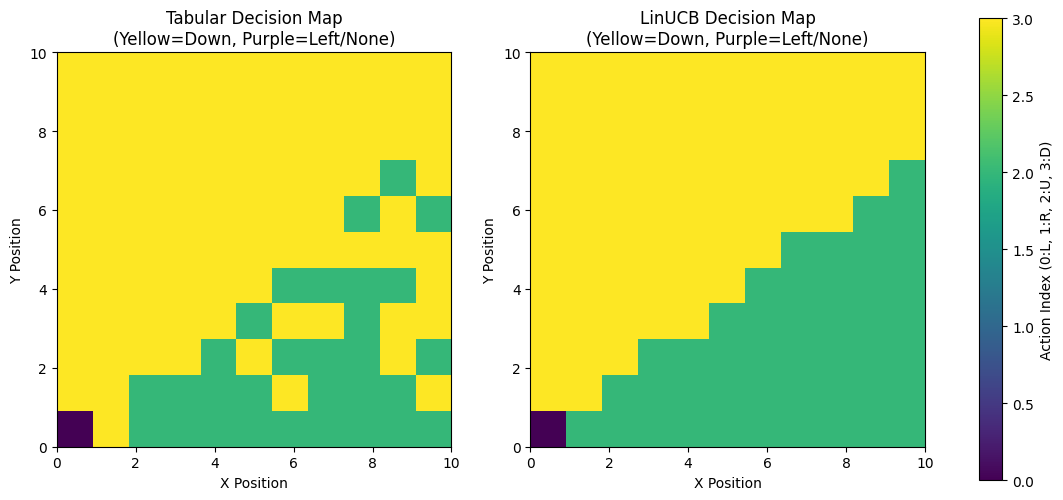

In [10]:
def plot_decision_surface(steps=500):
    # Initialize both models
    q_values = {(x,y): np.zeros(len(actions)) for x in range(11) for y in range(11)}
    counts = {(x,y): np.zeros(len(actions)) for x in range(11) for y in range(11)}
    A = [np.identity(2) for _ in actions]
    b = [np.zeros(2) for _ in actions]

    # Quick training phase for LinUCB to see some patterns
    pos = [5, 5]
    for t in range(steps):
        state = tuple(pos)
        context = np.array(pos)
        # Mix of actions to gather data
        action = linucb_action(context, A, b, alpha=1.0)
        reward = np.random.normal(loc=true_rewards[action], scale=0.1)
        linucb_update(action, context, reward, A, b)
        # Update tabular too for comparison
        counts[state][action] += 1
        q_values[state][action] += (reward - q_values[state][action]) / counts[state][action]
        # Random-ish walk
        pos = [np.random.randint(0,11), np.random.randint(0,11)]

    # Prepare Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, method in enumerate(['Tabular', 'LinUCB']):
        grid = np.zeros((11, 11))
        for x in range(11):
            for y in range(11):
                if method == 'Tabular':
                    grid[y, x] = np.argmax(q_values[(x, y)]) if np.sum(counts[(x,y)]) > 0 else -1
                else:
                    grid[y, x] = linucb_action(np.array([x, y]), A, b, alpha=0.0) # Greedy

        im = axes[i].imshow(grid, origin='lower', cmap='viridis', extent=[0, 10, 0, 10])
        axes[i].set_title(f"{method} Decision Map\n(Yellow=Down, Purple=Left/None)")
        axes[i].set_xlabel("X Position")
        axes[i].set_ylabel("Y Position")

    plt.colorbar(im, ax=axes.ravel().tolist(), label="Action Index (0:L, 1:R, 2:U, 3:D)")
    plt.show()

plot_decision_surface()

### Summary of Experiments

| Concept | Scenario A (MAB) | Scenario B (CMAB) |
| :--- | :--- | :--- |
| **Context** | Invariant (Position ignored) | Aware (Position-based) |
| **Goal** | Find globally best action | Find best action for specific state |
| **Method** | Epsilon-Greedy / Noisy Argmax | Tabular UCB / LinUCB |

#### Key Hyperparameter Impacts:
1.  **Epsilon ($\epsilon$):** High value ensures more discovery but lowers short-term reward.
2.  **C / Alpha:** Controls the 'curiosity' based on uncertainty. High values prevent the agent from getting stuck in local optima early on.
3.  **Learning Rate:** Determines how fast the agent forgets old reward estimates for new ones.

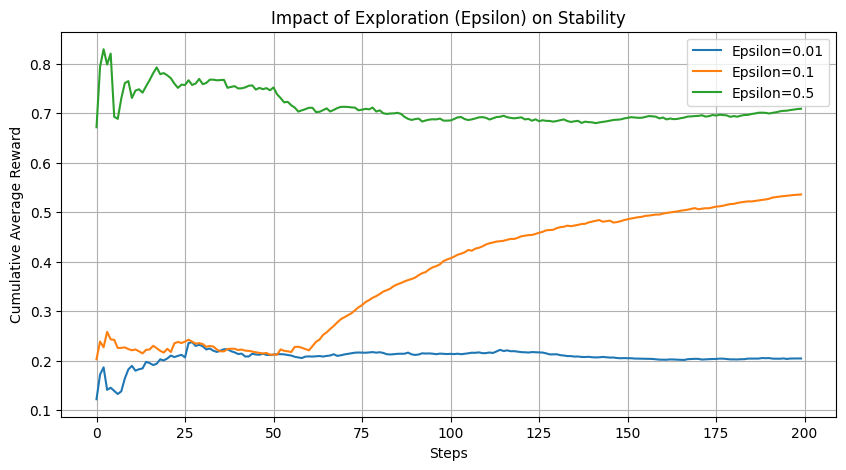

In [11]:
def compare_hyperparameters():
    epsilons = [0.01, 0.1, 0.5]
    plt.figure(figsize=(10, 5))

    for eps in epsilons:
        # Simplified tracking for comparison
        q_values = np.zeros(len(actions))
        rewards = []
        avg_r = []
        for _ in range(200):
            action = np.random.choice(len(actions)) if np.random.rand() < eps else np.argmax(q_values)
            reward = np.random.normal(true_rewards[action], 0.1)
            q_values[action] += 0.1 * (reward - q_values[action])
            rewards.append(reward)
            avg_r.append(np.mean(rewards))
        plt.plot(avg_r, label=f'Epsilon={eps}')

    plt.title("Impact of Exploration (Epsilon) on Stability")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_hyperparameters()